In [104]:
from typing import Annotated, Sequence, List, Literal, TypedDict 
from pydantic import BaseModel, Field 
from langchain_core.messages import HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults 
from langgraph.types import Command 
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.agents import create_agent 
from IPython.display import Image, display 
from dotenv import load_dotenv
from langchain_experimental.tools import PythonREPLTool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.types import interrupt, Command
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph import add_messages
from typing import TypedDict   
import json

load_dotenv()

llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite')

tavily_search = TavilySearchResults(max_results=2)

python_repl_tool = PythonREPLTool()

In [105]:
from operator import add


class Supervisor(BaseModel):
    next: Literal["interviewer","scenario-generator", "teacher","hint-generator"] = Field(
        description="Determines which specialist to activate next in the workflow sequence: "
                    "'interviewer' when needed to evaluate,"
                    "'scenario-generator' when new scenarios need to be created or explored, "
                    "'teacher' when the user needs guidance or instruction,"
                    "'hint-generator' when user explicitly requests hints or assistance."
    )
    reason: str = Field(
        description="Detailebd justification for the routing decision, explaining the rationale behind selecting the particular specialist and how this advances the task toward completion."
    )

class query_evaluation(BaseModel):
    is_technical: bool = Field(
        description="AIMessage indicating whether the user's query is technical in nature, relevant to system design, SQL, API design, or any other technical topic."
    )

class Scenario(BaseModel):
    title: str = Field(description="Short title of the interview scenario")
    description: str = Field(
        description="Detailed description of the interview scenario"
    )
    difficulty: Literal["easy", "intermediate", "hard"]
    constraints: List = Field(
        description="Any constraints or limitations for the interview scenario"
    )

class InterviewSummary(BaseModel):
    overall_assessment: str 
    strengths: list[str]
    weaknesses: list[str]
    covered_topics: list[str]
    pending_topics: list[str]
    score: float = Field(
        description="""Score rubric
        9-10: Excellent answer
        7-8: Mostly correct with minor omissions
        5-6: Basic understanding
        3-4: Major misconceptions
        0-2: Incorrect"""
    )
    next_question: str

class InterviewState(MessagesState):
    scenario: Scenario

    previous_questions: Annotated[list[str], add]
    current_question: str

    interview_summary: InterviewSummary
    avg_score: float

    question_number: int
    follow_up_count: int
    failure_count: int

    interview_stage: Literal[
        "scenario",
        "waiting_for_answer",
        "evaluating",
        "completed"
    ]




In [106]:
def supervisor_node(state: MessagesState) -> Command[Literal["interviewer","scenario-generator", "teacher","hint-generator"]]:

    system_prompt = ('''
                 
        You are a workflow supervisor managing a team of three specialized agents: Prompt Enhancer, Researcher, and Coder. Your role is to orchestrate the workflow by selecting the most appropriate next agent based on the current state and needs of the task. Provide a clear, concise rationale for each decision to ensure transparency in your decision-making process.

        **Team Members**:
        1. Scenario-Generator
        - Creates interview scenarios.
        - Generates new situations for the user.

        2. Teacher
        - Explains concepts.
        - Teaches system design, SQL, API design, etc.

        3. Interviewer
        - Reviews the user's answer.
        - Scores the answer.
        - Provided follow-up questions based on the user's answer.
        - Provides strengths and weaknesses.

        4. Hint-Generator
        - Generates hints and assistance based on the user's needs.

        **Your Responsibilities**:
        1. Analyze each user request and agent response for completeness, accuracy, and relevance.
        2. Route the task to the most appropriate agent at each decision point.
        3. Maintain workflow momentum by avoiding redundant agent assignments.
        4. Continue the process until the user's request is fully and satisfactorily resolved.

        Your objective is to create an efficient workflow that leverages each agent's strengths while minimizing unnecessary steps, ultimately delivering complete and accurate solutions to user requests.
                 
    ''')
    
    messages = [
        {"role": "system", "content": system_prompt},  
    ] + state["messages"] 

    response = llm.with_structured_output(Supervisor).invoke(messages)

    goto = response.next
    reason = response.reason

    print(f"--- Workflow Transition: Supervisor → {goto.upper()} ---")
    
    return Command(
        update={
            "messages": [
                AIMessage(content=reason, name="supervisor")
            ]
        },
        goto=goto,  
    )

In [107]:
def scenario_generator_node(state: InterviewState) -> Command[Literal["supervisor"]]:

    query_evaluation_prompt = f"""
    You are a query evaluation specialist with expertise in assessing the clarity, specificity, and technical relevance of user queries. Your task is to evaluate the user's initial query and determine whether it is sufficiently clear and actionable for generating interview scenarios.
    The topic should be related to system design, SQL, API design. The difficulty level should be clearly defined as easy, intermediate, or hard. If the query is vague or lacks specificity, you must enhance it to ensure it is actionable for scenario generation.
    """

    messages = [
        {"role": "system", "content": query_evaluation_prompt}
    ] + state["messages"]

    llm_response = llm.with_structured_output(query_evaluation).invoke(messages)
    
    if not llm_response.is_technical:
        print(f"--- Workflow Transition: Scenario Generator → Supervisor (Query Not Technical) ---")
        return Command(
            update={
                "messages": [
                    HumanMessage(content="The user's query is not technical or lacks clarity. It needs to be enhanced for scenario generation.", name="scenario-generator")
                ]
            },
            goto="END",
        )       

    enhancer_prompt = f"""
    You are a Query Refinement Specialist.
    
    Your ONLY responsibility is to refine the user's selected interview topic and difficulty level.
    Responsibilities:
    1. Normalize and clarify the topic if it is ambiguous.
    2. Expand the topic with relevant technical context that will help another agent generate a high-quality interview scenario.
    3. Interpret the difficulty level (Beginner, Intermediate, Advanced) and include what depth is expected.
    4. Make reasonable assumptions when necessary.
    5. Do NOT generate an interview scenario.
    6. Do NOT generate interview questions.
    7. Do NOT solve the problem.
    8. Do NOT ask the user any questions.

    Output only a refined specification that another Scenario Generator can use.
    """
    
    messages = [
        {"role": "system", "content": enhancer_prompt}
    ] + state["messages"]
    enhanced_query = llm.invoke(messages).content

    print(f"--- Workflow Transition: Scenario Generator → Supervisor (Query Enhanced) ---")
    print(f"Enhanced Query: {enhanced_query}")
    
    
    system_prompt = ('''
        You are a Scenario Generator, responsible for creating interview scenarios. Your task is to generate new situations for the user to engage with, ensuring that each scenario is unique, relevant, and challenging. Provide a clear and concise description of each scenario, including any necessary context or background information.

        **Your Responsibilities**:
        1. Generate interview scenarios based on the user's choosen topic and difficulty level.
        2. Ensure that each scenario is unique and provides a meaningful challenge for the user.
        3. Provide any necessary context or background information to help the user understand the scenario.

        Your objective is to create engaging and thought-provoking scenarios that will help the user develop their skills and knowledge in a meaningful way.
    ''')
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": enhanced_query},
    ] + state["messages"]

    response = llm.with_structured_output(Scenario).invoke(messages)
    scenario = response.model_dump()

    print(f"--- Workflow Transition: Scenario Generator → Supervisor ---")
    
    return Command(
        update={
            "scenario": scenario,

            "current_question": "",

            "previous_questions": [],

            "question_number": 1,
            "follow_up_count": 0,
            "failure_count": 0,

            "interview_summary": {
                "overall_assessment": "",
                "strengths": [],
                "weaknesses": [],
                "covered_topics": [],
                "pending_topics": [],
                "score": 0.0,
                "next_question": ""
            },
            "avg_score": 0.0,

            "messages": [
                    AIMessage(content= json.dumps(scenario, indent=2),
                    name="scenario-generator")
            ]
        },
        goto="wait_for_user"
    )

In [108]:
def wait_for_user_node(state: InterviewState) -> Command[Literal["supervisor"]]:
    answer = interrupt(
        {
            "type": "await_answer"
        }
    )
    return Command(
        update={
            "messages": [
                HumanMessage(content=answer)
            ]
        },
        goto="supervisor",
    )

In [109]:
def teacher_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    print(f"--- Workflow Transition: Teacher → Supervisor ---")

def interviewer_node(state: InterviewState) -> Command[Literal["supervisor"]]:
    system_prompt = ("""
    You are an experienced technical interviewer conducting an adaptive system design interview.

    Your goals are:
    1. Evaluate the candidate's latest answer.
    2. Update the interview summary based on the entire interview so far.
    3. Generate the next interview question.

    Evaluation Criteria
    - Technical accuracy
    - Completeness
    - Clarity
    - Relevance
    - Depth of reasoning

    When updating the interview summary:
    - The interview summary is the long-term memory of the interview.
    - It should represent the candidate's overall performance across all previous questions, not only the latest answer.
    - Preserve previous strengths unless the latest answer contradicts them.
    - Add any newly demonstrated strengths.
    - Preserve weaknesses unless the candidate has clearly improved.
    - Remove weaknesses that have now been addressed.
    - Add newly discovered weaknesses.
    - Add newly covered topics.
    - Remove covered topics from pending topics.
    - Keep the summary concise.

    Choose the next question by considering:
    1. The latest answer (highest priority)
    2. The interview summary
    3. Covered topics
    4. Pending topics
    5. The interview scenario

    Decision rules:

    - If the latest answer reveals a weakness, ask a follow-up on that weakness.
    - If the latest answer is strong, move to the next relevant concept or increase the difficulty.
    - Occasionally introduce a realistic production failure, but only when it fits naturally.
    - Never restart the interview.
    - Never repeat a question that has already been asked.
    - Ask exactly one question.
    - If the candidate has demonstrated sufficient mastery of all planned topics, ask a final wrap-up question or conclude the interview instead of introducing unnecessary new topics.
                        
    Guidelines:
    - Keep the interview conversational and realistic.
    - Failure simulations should feel natural and should not be introduced after every answer.
    - Build upon previous questions instead of changing topics abruptly.
    - Encourage the candidate to explain their reasoning whenever appropriate.
    - The next interview question should feel like a natural continuation of the conversation rather than a randomly selected interview question.
    """)

    prev_details = state["interview_summary"]
    summary = prev_details["overall_assessment"]
    strength = prev_details["strengths"]
    weakness = prev_details["weaknesses"]
    covered_topics = prev_details["covered_topics"]
    pending_topics = prev_details["pending_topics"]
    avg_score = state["avg_score"]
 
    current_question = state["current_question"]
    prev_questions = state["previous_questions"]
    current_answer = current_answer = next(
                        m.content
                        for m in reversed(state["messages"])
                        if isinstance(m, HumanMessage)
                    )
    print("===============================")
    print("current_answer : ", current_answer)
    print("===============================")

    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "system", "content":
            f"""Scenario: 
                Title:{state["scenario"]["title"]}
                Description:{state["scenario"]["description"]}
                Difficulty: {state["scenario"]["difficulty"]}
                Constraints:{state["scenario"]["constraints"]}
        """},
        {"role":"user", "content": f"""
            Interview Question: {current_question}
            Candidate's Answer:{current_answer}
            Prev Question: {prev_questions}
            """
        },
        {"role": "system", "content": f"""
            Current Interview Summary:
                Overall: {summary}
                Strengths: {strength}
                Weaknesses: {weakness}
                Covered Topics: {covered_topics}
                Pending Topics:{pending_topics}
                Average Score:{avg_score}
        """},
    ]

    evaluation = llm.with_structured_output(InterviewSummary).invoke(messages)

    updated_summary = {
        "overall_assessment": evaluation.overall_assessment,
        "strengths": evaluation.strengths,
        "weaknesses": evaluation.weaknesses,
        "covered_topics": evaluation.covered_topics,
        "pending_topics": evaluation.pending_topics,
        "next_question": evaluation.next_question,
        "score": evaluation.score
    }

    return Command(
    update={
        "interview_summary": updated_summary,
        "previous_questions": [current_question],
        "current_question": evaluation.next_question,
        "question_number": state["question_number"] + 1,
        "avg_score": (
            (avg_score * state["question_number"] + evaluation.score) / (state["question_number"] + 1)
        ),
        "messages": [
            AIMessage(
                content=evaluation.next_question,
                name="interviewer"
            )
        ]
    },
    goto="wait_for_user"
)   

def hint_generator_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    print(f"--- Workflow Transition: Hint Generator → Supervisor ---")


In [110]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()


graph = StateGraph(InterviewState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("scenario-generator", scenario_generator_node)
graph.add_node("wait_for_user", wait_for_user_node)

graph.add_node("teacher", teacher_node)
graph.add_node("interviewer", interviewer_node)
graph.add_node("hint-generator", hint_generator_node)
graph.add_edge(START, "supervisor")

app = graph.compile(checkpointer=checkpointer)

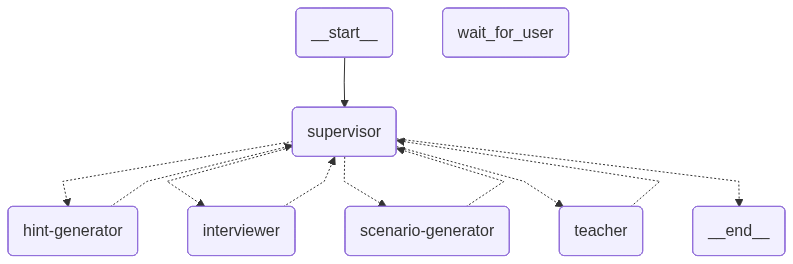

In [111]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [115]:
import pprint
import uuid
config = {
    "configurable": {
        "thread_id": uuid.uuid4()
    }
}

inputs = {
    "messages": [
        HumanMessage(
            content="topic: Load Balancer, Difficulty: easy "
        )
    ]
}

for event in app.stream(inputs, config=config):
    for key, value in event.items():
        if value is None:
            continue
        last_message = value.get("messages", [])[-1] if "messages" in value else None
        if last_message:
            pprint.pprint(f"Output from node '{key}':")
            pprint.pprint(last_message, indent=2, width=80, depth=None)
            print()

--- Workflow Transition: Supervisor → SCENARIO-GENERATOR ---
"Output from node 'supervisor':"
AIMessage(content='The user has defined the topic and difficulty level, so the first logical step is to generate an initial interview scenario to begin the assessment process.', additional_kwargs={}, response_metadata={}, name='supervisor', id='496852c3-13de-41e0-b923-39b76f1b12a6', tool_calls=[], invalid_tool_calls=[])

--- Workflow Transition: Scenario Generator → Supervisor (Query Enhanced) ---
Enhanced Query: []


c:\Users\Rahul Kaddi\my-projects\SystemPilot\server\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3102: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


--- Workflow Transition: Scenario Generator → Supervisor ---
"Output from node 'scenario-generator':"
AIMessage(content='{\n  "title": "Basic Load Balancer Implementation",\n  "description": "You are a junior DevOps engineer tasked with setting up a simple Round Robin load balancer for a company\'s web application. The application is currently running on two identical servers, and you need to explain how the load balancer distributes incoming traffic and what happens if one of those servers suddenly becomes unresponsive.",\n  "difficulty": "easy",\n  "constraints": [\n    "Explain the concept of Round Robin in simple terms",\n    "Identify how the load balancer detects a server failure",\n    "Keep the explanation under 3 minutes",\n    "Do not use complex technical jargon without providing a brief definition"\n  ]\n}', additional_kwargs={}, response_metadata={}, name='scenario-generator', id='257f6576-f6ff-4a05-a562-e0fc0b965185', tool_calls=[], invalid_tool_calls=[])



In [117]:
response2 =  """Session persistence (also called sticky sessions) ensures that a user's requests are consistently routed to the same backend server throughout their session. This is especially important during a shopping cart checkout because if session data, such as the cart contents or authentication state, is stored only in the server's local memory, sending subsequent requests to a different server could result in the user losing their cart or being logged out.
By enabling session persistence, the load balancer ensures that all requests from that user continue to reach the same backend server, providing a seamless experience during checkout.
However, there are trade-offs. First, it can lead to uneven load distribution because some servers may end up handling more long-lived sessions than others. Second, if the server handling a sticky session fails, the user may lose their session unless the session data is replicated or stored externally. Third, it reduces flexibility in routing traffic because the load balancer is constrained to send requests to a specific server instead of the least-loaded healthy server.
In modern architectures, instead of relying heavily on sticky sessions, it's generally preferable to build stateless application servers. Session data can be stored in a shared external store such as Redis or a database. This allows any backend server to handle any request, improving scalability, fault tolerance, and load balancing efficiency while still preserving the user's session if a server fails."""

response1 = """A load balancer is necessary because a single server becomes a bottleneck as traffic increases. If that server crashes or becomes overloaded, the entire website becomes unavailable. By placing a load balancer in front of multiple backend servers, incoming requests can be distributed evenly, improving both scalability and availability.
For traffic distribution, I would use the Round Robin algorithm because it's simple and works well when all backend servers have similar capacity. If some servers are more powerful, a Weighted Round Robin approach would be better.
The load balancer should also perform periodic health checks on backend servers. If a server fails to respond to these health checks, it is marked as unhealthy and no new requests are forwarded to it until it recovers.
Regarding Layer 4 and Layer 7 routing, Layer 4 operates at the transport layer and forwards traffic based on IP addresses and TCP/UDP ports, making it very fast. Layer 7 operates at the application layer and can inspect HTTP requests, allowing routing based on URL paths, headers, or cookies. For an e-commerce application, Layer 7 would be more suitable because it enables routing requests like /checkout or /images to different backend services while also supporting features such as SSL termination and session persistence."""

for event in app.stream(
    Command(
        resume=response2),
    config=config,
):
    print(event)

{'wait_for_user': {'messages': [HumanMessage(content="Session persistence (also called sticky sessions) ensures that a user's requests are consistently routed to the same backend server throughout their session. This is especially important during a shopping cart checkout because if session data, such as the cart contents or authentication state, is stored only in the server's local memory, sending subsequent requests to a different server could result in the user losing their cart or being logged out.\nBy enabling session persistence, the load balancer ensures that all requests from that user continue to reach the same backend server, providing a seamless experience during checkout.\nHowever, there are trade-offs. First, it can lead to uneven load distribution because some servers may end up handling more long-lived sessions than others. Second, if the server handling a sticky session fails, the user may lose their session unless the session data is replicated or stored externally. Th